# Task 1.1 – Gauss-Seidel Solver: Python List vs `array` vs NumPy

Benchmark the **same** Gauss-Seidel kernel implemented with three different data structures and measure how the wall-clock time scales with grid size $N$.


- Grid: $N \times N$, unit square, zero boundary conditions  
- Interior: random initial values  
- 100 Gauss-Seidel iterations per measurement  
- Grid sizes tested: $N \in \{16, 32, 64, 128, 256\}$

In [2]:
from array import array
import random
import time

import numpy as np
import matplotlib.pyplot as plt

ITERS      = 100
GRID_SIZES = [16, 32, 64, 128, 256]
SEED       = 42

## Grid Initialisation

Each helper creates an $N \times N$ grid with the same random values and zero boundary conditions, stored in the respective data structure.

In [3]:
def make_grid_list(N):
    random.seed(SEED)
    f = [[0.0] * N for _ in range(N)]
    for i in range(1, N - 1):
        for j in range(1, N - 1):
            f[i][j] = random.random()
    return f

def make_grid_array(N):
    f = make_grid_list(N)
    return array('d', (f[i][j] for i in range(N) for j in range(N))), N

def make_grid_numpy(N):
    rng = np.random.default_rng(SEED)
    f = np.zeros((N, N))
    f[1:-1, 1:-1] = rng.random((N - 2, N - 2))  # only fill interior
    return f


In [4]:
def gauss_seidel_list(f):
    N = len(f)
    for i in range(1, N - 1):
        for j in range(1, N - 1):
            f[i][j] = 0.25 * (f[i][j+1] + f[i][j-1] +
                               f[i+1][j] + f[i-1][j])
    return f

def gauss_seidel_array(f, N):
    for i in range(1, N - 1):
        for j in range(1, N - 1):
            idx = i * N + j
            f[idx] = 0.25 * (f[idx + 1] + f[idx - 1] +
                              f[idx + N] + f[idx - N])
    return f

def gauss_seidel_numpy(f):
    for i in range(1, f.shape[0] - 1):
        for j in range(1, f.shape[1] - 1):
            f[i, j] = 0.25 * (f[i, j+1] + f[i, j-1] +
                               f[i+1, j] + f[i-1, j])
    return f

## Benchmark


In [5]:
times_list  = []
times_array = []
times_numpy = []

for N in GRID_SIZES:
    print(f"N = {N:4d} ...", end="  ", flush=True)

    # list-of-lists
    f = make_grid_list(N)
    t0 = time.perf_counter()
    for _ in range(ITERS):
        gauss_seidel_list(f)
    times_list.append(time.perf_counter() - t0)

    # flat array('d')
    f, _ = make_grid_array(N)
    t0 = time.perf_counter()
    for _ in range(ITERS):
        gauss_seidel_array(f, N)
    times_array.append(time.perf_counter() - t0)

    # NumPy 2-D array
    f = make_grid_numpy(N)
    t0 = time.perf_counter()
    for _ in range(ITERS):
        gauss_seidel_numpy(f)
    times_numpy.append(time.perf_counter() - t0)

    print(f"list={times_list[-1]:.4f}s   array={times_array[-1]:.4f}s   numpy={times_numpy[-1]:.4f}s")

N =   16 ...  list=0.0076s   array=0.0082s   numpy=0.0106s
N =   32 ...  list=0.0105s   array=0.0166s   numpy=0.0474s
N =   64 ...  list=0.0436s   array=0.0725s   numpy=0.1980s
N =  128 ...  list=0.1809s   array=0.3044s   numpy=0.8173s
N =  256 ...  list=0.7657s   array=1.2017s   numpy=3.2487s


## Performance Plot

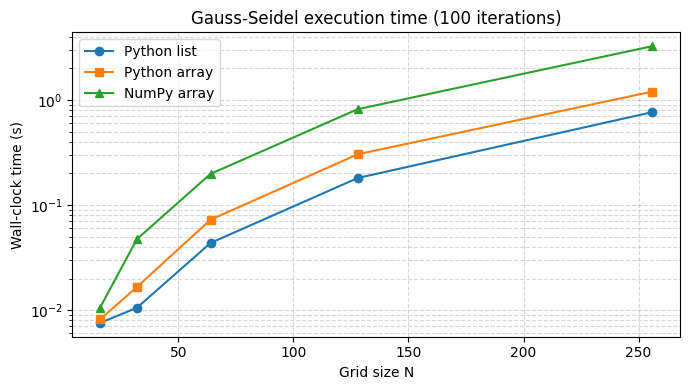

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(GRID_SIZES, times_list,  "o-", label="Python list")
ax.plot(GRID_SIZES, times_array, "s-", label="Python array")
ax.plot(GRID_SIZES, times_numpy, "^-", label="NumPy array")
ax.set_xlabel("Grid size N")
ax.set_ylabel("Wall-clock time (s)")
ax.set_title(f"Gauss-Seidel execution time ({ITERS} iterations)")
ax.set_yscale("log")
ax.legend()
ax.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


---
## Task 1.2 – Profile the Code


We profile `gauss_seidel_list` on a 128×128 grid for 100 iterations, the baseline that will guide optimisation.

### cProfile

In [9]:
import cProfile
import pstats
import io

N_PROF = 128

def run_list(iters=ITERS):
    f = make_grid_list(N_PROF)
    for _ in range(iters):
        gauss_seidel_list(f)

pr = cProfile.Profile()
pr.enable()
run_list()
pr.disable()

stream = io.StringIO()
ps = pstats.Stats(pr, stream=stream)
ps.sort_stats("tottime")         
ps.print_stats("ipykernel")       
print(stream.getvalue())


         16783 function calls (16778 primitive calls) in 0.337 seconds

   Ordered by: internal time
   List reduced from 138 to 10 due to restriction <'ipykernel'>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      100    0.229    0.002    0.229    0.002 /var/folders/66/s_wdz_l53qz4tp6lwx4654nh0000gn/T/ipykernel_30173/2194687373.py:1(gauss_seidel_list)
        1    0.002    0.002    0.004    0.004 /var/folders/66/s_wdz_l53qz4tp6lwx4654nh0000gn/T/ipykernel_30173/2803086279.py:1(make_grid_list)
        1    0.000    0.000    0.177    0.177 /var/folders/66/s_wdz_l53qz4tp6lwx4654nh0000gn/T/ipykernel_30173/1977942482.py:1(<module>)
        1    0.000    0.000    0.177    0.177 /var/folders/66/s_wdz_l53qz4tp6lwx4654nh0000gn/T/ipykernel_30173/1977942482.py:7(run_list)
        2    0.000    0.000    0.063    0.032 /Users/ermiaghaffari/Desktop/DD2358/.venv/lib/python3.14/site-packages/ipykernel/iostream.py:158(_handle_event)
        2    0.000    0.000    0.043    0

### line_profiler

`line_profiler` shows the time spent on **every individual line** inside the function.  
Install once with `pip install line_profiler`, then use the `%lprun` magic.

In [11]:
%load_ext line_profiler

f_prof = make_grid_list(N_PROF)
%lprun -f gauss_seidel_list run_list()

Timer unit: 1e-09 s

Total time: 2.86176 s
File: /var/folders/66/s_wdz_l53qz4tp6lwx4654nh0000gn/T/ipykernel_30173/2194687373.py
Function: gauss_seidel_list at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def gauss_seidel_list(f):
     2       100      74000.0    740.0      0.0      N = len(f)
     3     12700    3735000.0    294.1      0.1      for i in range(1, N - 1):
     4   1600200  463877000.0    289.9     16.2          for j in range(1, N - 1):
     5   4762800 1504352000.0    315.9     52.6              f[i][j] = 0.25 * (f[i][j+1] + f[i][j-1] +
     6   3175200  889612000.0    280.2     31.1                                 f[i+1][j] + f[i-1][j])
     7       100     107000.0   1070.0      0.0      return f

### What the profiling tells us

**cProfile** show that virtually all time is spent inside `gauss_seidel_list` and the function call itself is the hotspot.

**line_profiler** reveals that the single update line:

```python
f[i][j] = 0.25 * (f[i][j+1] + f[i][j-1] + f[i+1][j] + f[i-1][j])
```

accounts for most of all time. The `for` loop lines consume the remaining.


---
## Task 1.3 – Cython Annotation





In [ ]:
%%writefile gauss_seidel_annotate.pyx

def gauss_seidel(f):
    N = len(f)
    for i in range(1, N - 1):
        for j in range(1, N - 1):
            f[i][j] = 0.25 * (f[i][j+1] + f[i][j-1] +
                               f[i+1][j] + f[i-1][j])
    return f

Writing gauss_seidel_annotate.pyx


In [17]:
import subprocess, pathlib

result = subprocess.run(
    ["cython", "-a", "gauss_seidel_annotate.pyx"],
    capture_output=True, text=True
)
print(result.stdout or "Done.")
if result.returncode != 0:
    print("STDERR:", result.stderr)

Done.


### Reading the annotation report

All the lines are still yellow. 

---
## Task 1.4 – Cython Optimisation

The annotation showed that every line in the plain Python loop is yellow (Python C-API overhead).  
The fix is to add **static type declarations**:

- `double[:, :]` typed memoryview which helps with direct C-level buffer access, no Python indexing
- `cdef int i, j` → loop variables become C `int`, no Python integer boxing
- `nogil` + `boundscheck(False)` → further reduces overhead

We compile the typed `.pyx`, then benchmark it against the three Task 1.1 implementations.

In [19]:
%%writefile cgs.pyx
# cython: boundscheck=False, wraparound=False, cdivision=True
import numpy as np

def gauss_seidel_cython(double[:, :] f):
    cdef int N = f.shape[0]
    cdef int i, j
    for i in range(1, N - 1):
        for j in range(1, N - 1):
            f[i, j] = 0.25 * (f[i, j+1] + f[i, j-1] +
                               f[i+1, j] + f[i-1, j])
    return f

Writing cgs.pyx


In [20]:
%%writefile setup_cgs.py
from setuptools import setup
from Cython.Build import cythonize
import numpy as np

setup(
    ext_modules=cythonize("cgs.pyx", compiler_directives={"language_level": "3"}),
    include_dirs=[np.get_include()],
)

Writing setup_cgs.py


In [22]:
import subprocess, sys

res = subprocess.run(
    [sys.executable, "setup_cgs.py", "build_ext", "--inplace"],
    capture_output=True, text=True
)
print(res.stdout[-1500:] if len(res.stdout) > 1500 else res.stdout)
if res.returncode != 0:
    print("STDERR:", res.stderr[-1000:])

Compiling cgs.pyx because it changed.
[1/1] Cythonizing cgs.pyx
running build_ext
building 'cgs' extension
creating build/temp.macosx-15.0-arm64-cpython-314
clang -fno-strict-overflow -Wsign-compare -Wunreachable-code -fno-common -dynamic -DNDEBUG -g -O3 -Wall -I/Users/ermiaghaffari/Desktop/DD2358/.venv/lib/python3.14/site-packages/numpy/_core/include -I/Users/ermiaghaffari/Desktop/DD2358/.venv/include -I/opt/homebrew/opt/python@3.14/Frameworks/Python.framework/Versions/3.14/include/python3.14 -c cgs.c -o build/temp.macosx-15.0-arm64-cpython-314/cgs.o
creating build/lib.macosx-15.0-arm64-cpython-314
clang -bundle -undefined dynamic_lookup build/temp.macosx-15.0-arm64-cpython-314/cgs.o -o build/lib.macosx-15.0-arm64-cpython-314/cgs.cpython-314-darwin.so
copying build/lib.macosx-15.0-arm64-cpython-314/cgs.cpython-314-darwin.so -> 



In [23]:
import importlib, cgs
importlib.reload(cgs)
from cgs import gauss_seidel_cython

times_cython = []

for N in GRID_SIZES:
    f = make_grid_numpy(N)    
    t0 = time.perf_counter()
    for _ in range(ITERS):
        gauss_seidel_cython(f)
    times_cython.append(time.perf_counter() - t0)
    print(f"N = {N:4d}  cython={times_cython[-1]:.4f}s  "
          f"speedup_vs_list={times_list[GRID_SIZES.index(N)] / times_cython[-1]:.1f}x")

N =   16  cython=0.0002s  speedup_vs_list=36.7x
N =   32  cython=0.0006s  speedup_vs_list=16.6x
N =   64  cython=0.0039s  speedup_vs_list=11.2x
N =  128  cython=0.0105s  speedup_vs_list=17.1x
N =  256  cython=0.0416s  speedup_vs_list=18.4x


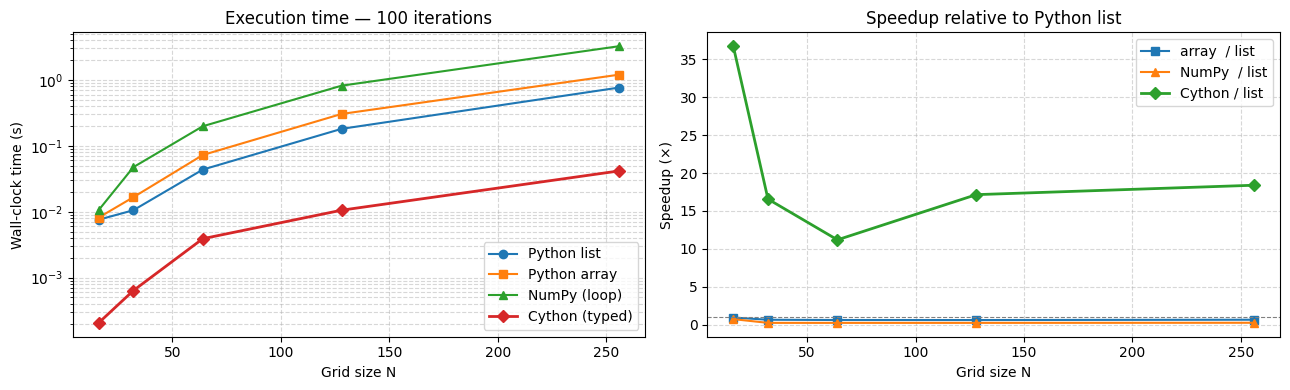

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: absolute time ───────────────────────────────────────────────────
ax = axes[0]
ax.plot(GRID_SIZES, times_list,   "o-",  label="Python list")
ax.plot(GRID_SIZES, times_array,  "s-",  label="Python array")
ax.plot(GRID_SIZES, times_numpy,  "^-",  label="NumPy (loop)")
ax.plot(GRID_SIZES, times_cython, "D-",  label="Cython (typed)", linewidth=2)
ax.set_xlabel("Grid size N")
ax.set_ylabel("Wall-clock time (s)")
ax.set_title(f"Execution time — {ITERS} iterations")
ax.set_yscale("log")
ax.legend()
ax.grid(True, which="both", linestyle="--", alpha=0.5)

# ── Right: speedup vs Python list ─────────────────────────────────────────
ax = axes[1]
ax.plot(GRID_SIZES, [l/a for l, a in zip(times_list, times_array)],  "s-", label="array  / list")
ax.plot(GRID_SIZES, [l/n for l, n in zip(times_list, times_numpy)],  "^-", label="NumPy  / list")
ax.plot(GRID_SIZES, [l/c for l, c in zip(times_list, times_cython)], "D-", label="Cython / list", linewidth=2)
ax.axhline(1, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Grid size N")
ax.set_ylabel("Speedup (×)")
ax.set_title("Speedup relative to Python list")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()